In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\somil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\somil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\somil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\somil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [5]:
resume_df = pd.read_csv("data/resume_dataset.csv")
job_df = pd.read_csv("data/job_descriptions.csv")

In [6]:
resume_df.shape, job_df.shape

((308, 3), (87, 5))

In [7]:
resume_df.head()

,category,job_title,Text
0,Web Development,Frontend Developer,"Motivated Frontend Developer skilled in react,..."
1,Business Analyst,Business Analyst,Business Analyst candidate with practical expo...
2,Machine Learning,Machine Learning Engineer,Machine Learning Engineer candidate with pract...
3,DevOps,DevOps Engineer,Passionate DevOps Engineer proficient in linux...
4,DevOps,Site Reliability Engineer,Motivated Site Reliability Engineer skilled in...


In [8]:
job_df.head()

,job_id,category,job_title,job_description,job_skill_set
0,1001,Data Science,Data Scientist,We are looking for a Data Scientist to join ou...,"python, pandas, numpy, statistics, sql, data v..."
1,1002,Data Science,Data Scientist,Our company is seeking a Data Scientist experi...,"python, pandas, numpy, statistics, sql, data v..."
2,1003,Data Science,Data Scientist,We are looking for a Data Scientist to join ou...,"python, pandas, numpy, statistics, sql, data v..."
3,1004,Data Science,Data Analyst,Our company is seeking a Data Analyst experien...,"python, pandas, numpy, statistics, sql, data v..."
4,1005,Data Science,Data Analyst,Our company is seeking a Data Analyst experien...,"python, pandas, numpy, statistics, sql, data v..."


In [9]:
resume_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   category   308 non-null    str  
 1   job_title  308 non-null    str  
 2   Text       303 non-null    str  
dtypes: str(3)
memory usage: 7.3 KB


In [10]:
resume_df.isnull().sum()

category     0
job_title    0
Text         5
dtype: int64

In [11]:
job_df.isnull().sum()

job_id             0
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64

In [12]:
resume_df = resume_df.dropna(subset=['Text']).reset_index(drop=True)

In [13]:
resume_df.duplicated().sum()

np.int64(8)

In [14]:
resume_df = resume_df.drop_duplicates().reset_index(drop=True)
job_df = job_df.drop_duplicates(subset=['job_id']).reset_index(drop=True)
resume_df.shape, job_df.shape

((295, 3), (87, 5))

C:\Users\somil\AppData\Local\Temp\ipykernel_12792\1435605290.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=resume_df['category'], order=resume_df['category'].value_counts().index, palette='viridis')


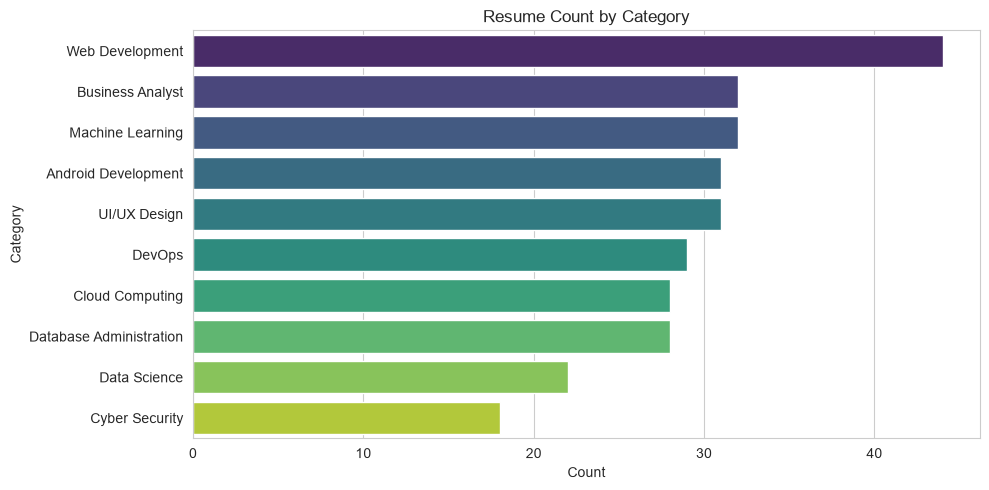

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(y=resume_df['category'], order=resume_df['category'].value_counts().index, palette='viridis')
plt.title("Resume Count by Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

C:\Users\somil\AppData\Local\Temp\ipykernel_12792\211265131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=job_df['category'], order=job_df['category'].value_counts().index, palette='mako')


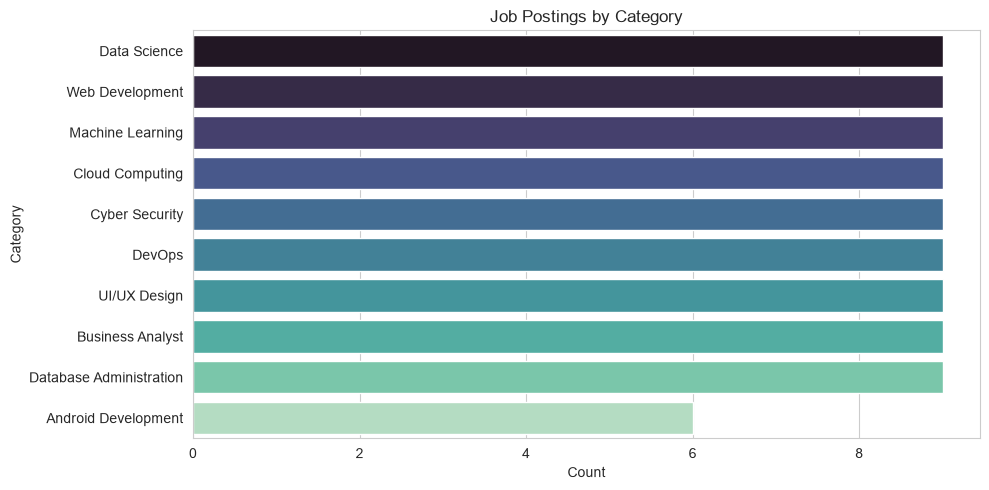

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(y=job_df['category'], order=job_df['category'].value_counts().index, palette='mako')
plt.title("Job Postings by Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

C:\Users\somil\AppData\Local\Temp\ipykernel_12792\1661470195.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette='crest')


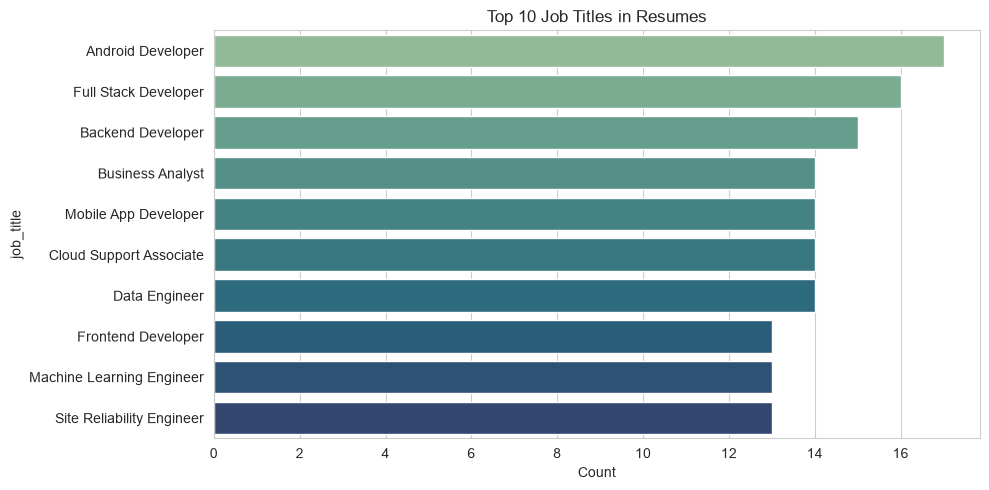

In [17]:
top_titles = resume_df['job_title'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_titles.values, y=top_titles.index, palette='crest')
plt.title("Top 10 Job Titles in Resumes")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

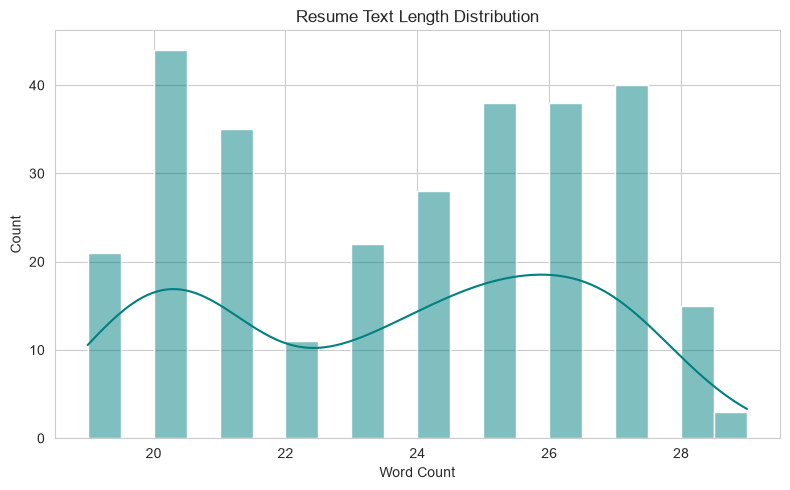

In [18]:
resume_df['text_length'] = resume_df['Text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(resume_df['text_length'], bins=20, kde=True, color='teal')
plt.title("Resume Text Length Distribution")
plt.xlabel("Word Count")
plt.tight_layout()
plt.show()

In [19]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [20]:
resume_df['clean_text'] = resume_df['Text'].apply(clean_text)
job_df['clean_description'] = job_df['job_description'].apply(clean_text)

In [21]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

In [22]:
resume_df['processed_text'] = resume_df['clean_text'].apply(preprocess_text)
job_df['processed_description'] = job_df['clean_description'].apply(preprocess_text)

C:\Users\somil\AppData\Local\Temp\ipykernel_12792\691935608.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_freq.values, y=skill_freq.index, palette='flare')


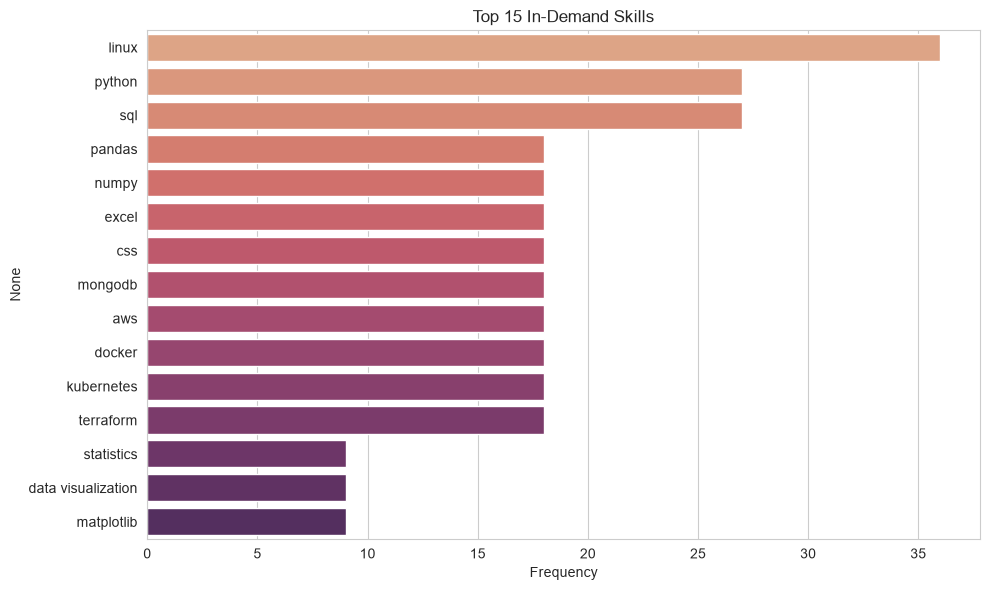

In [23]:
all_skills_raw = job_df['job_skill_set'].str.split(',')
skill_flat = [s.strip().lower() for sub in all_skills_raw for s in sub]
skill_freq = pd.Series(skill_flat).value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=skill_freq.values, y=skill_freq.index, palette='flare')
plt.title("Top 15 In-Demand Skills")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

master_skill_list = sorted(set(skill_flat))

In [24]:
def extract_skills(text, skill_list=master_skill_list):
    text = text.lower()
    found = [skill for skill in skill_list if skill in text]
    return list(set(found))

sample_resume_text = resume_df.loc[0, 'clean_text']
extract_skills(sample_resume_text)

['html', 'react', 'css', 'git']

In [25]:
corpus = list(job_df['processed_description'])
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
job_tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

In [26]:
def find_best_job_match(resume_text):
    resume_vec = tfidf_vectorizer.transform([resume_text])
    scores = cosine_similarity(resume_vec, job_tfidf_matrix)[0]
    best_index = int(np.argmax(scores))
    best_score = round(float(scores[best_index]) * 100, 2)
    return best_index, best_score

In [27]:
idx, score = find_best_job_match(resume_df.loc[0, 'processed_text'])
job_df.loc[idx, ['job_title', 'category']], score

(job_title    Backend Developer
 category       Web Development
 Name: 12, dtype: str,
 69.32)

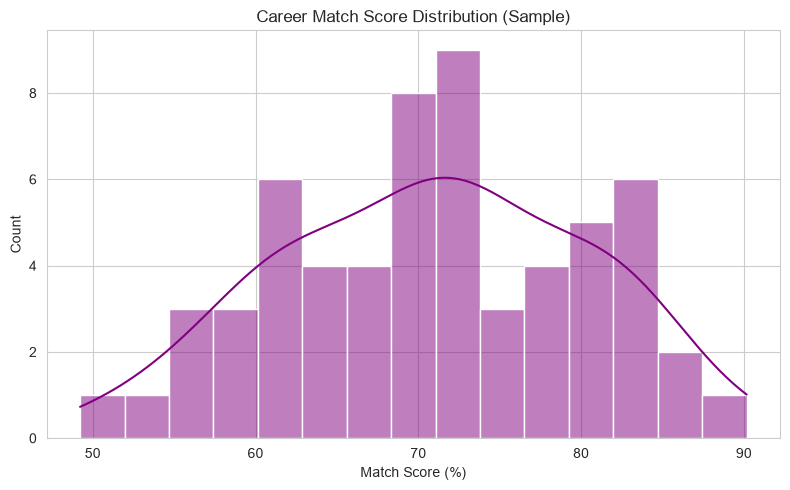

In [28]:
sample_scores = [find_best_job_match(t)[1] for t in resume_df['processed_text'].sample(60, random_state=1)]

plt.figure(figsize=(8,5))
sns.histplot(sample_scores, bins=15, kde=True, color='purple')
plt.title("Career Match Score Distribution (Sample)")
plt.xlabel("Match Score (%)")
plt.tight_layout()
plt.show()

In [29]:
session_memory = {}

class AgentState(TypedDict):
    resume_text: str
    clean_resume: str
    user_skills: List[str]
    best_job_index: int
    recommended_job: str
    match_score: float
    missing_skills: List[str]
    roadmap: List[str]
    suggested_projects: List[str]
    career_summary: str

In [30]:
def resume_analysis_node(state: AgentState):
    cleaned = clean_text(state['resume_text'])
    processed = preprocess_text(cleaned)
    return {"clean_resume": processed}

In [31]:
def skill_extraction_node(state: AgentState):
    skills = extract_skills(state['clean_resume'])
    return {"user_skills": skills}

In [32]:
def career_recommendation_node(state: AgentState):
    best_index, best_score = find_best_job_match(state['clean_resume'])
    job_title = job_df.loc[best_index, 'job_title']
    return {
        "best_job_index": best_index,
        "recommended_job": job_title,
        "match_score": best_score
    }

In [33]:
def skill_gap_node(state: AgentState):
    required = job_df.loc[state['best_job_index'], 'job_skill_set']
    required_skills = [s.strip().lower() for s in required.split(',')]
    missing = [s for s in required_skills if s not in state['user_skills']]
    return {"missing_skills": missing}

In [34]:
def career_score_node(state: AgentState):
    required = job_df.loc[state['best_job_index'], 'job_skill_set']
    required_skills = [s.strip().lower() for s in required.split(',')]
    if len(required_skills) == 0:
        skill_coverage = 0
    else:
        matched = len(set(state['user_skills']) & set(required_skills))
        skill_coverage = round((matched / len(required_skills)) * 100, 2)
    final_score = round((state['match_score'] + skill_coverage) / 2, 2)
    return {"match_score": final_score}

In [35]:
def learning_roadmap_node(state: AgentState):
    roadmap = [f"Learn and practice {skill}" for skill in state['missing_skills'][:5]]
    return {"roadmap": roadmap}

In [36]:
def career_report_node(state: AgentState):
    projects = [f"Build a mini project using {skill}" for skill in state['missing_skills'][:3]]
    summary = (
        f"Based on your resume, the best matching role is {state['recommended_job']} "
        f"with a career match score of {state['match_score']}%. "
        f"You already have {len(state['user_skills'])} relevant skills, "
        f"and {len(state['missing_skills'])} skills to develop further."
    )
    return {"suggested_projects": projects, "career_summary": summary}

In [37]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("resume_analysis", resume_analysis_node)
graph_builder.add_node("skill_extraction", skill_extraction_node)
graph_builder.add_node("career_recommendation", career_recommendation_node)
graph_builder.add_node("skill_gap", skill_gap_node)
graph_builder.add_node("career_score", career_score_node)
graph_builder.add_node("learning_roadmap", learning_roadmap_node)
graph_builder.add_node("career_report", career_report_node)

In [38]:
graph_builder.add_edge(START, "resume_analysis")
graph_builder.add_edge("resume_analysis", "skill_extraction")
graph_builder.add_edge("skill_extraction", "career_recommendation")
graph_builder.add_edge("career_recommendation", "skill_gap")
graph_builder.add_edge("skill_gap", "career_score")
graph_builder.add_edge("career_score", "learning_roadmap")
graph_builder.add_edge("learning_roadmap", "career_report")
graph_builder.add_edge("career_report", END)

In [39]:
career_mentor_graph = graph_builder.compile()

In [40]:
def run_career_mentor(resume_text, user_id="user_1"):
    result = career_mentor_graph.invoke({"resume_text": resume_text})
    session_memory[user_id] = result
    return result

In [41]:
sample_result = run_career_mentor(resume_df.loc[0, 'Text'], user_id="student_1")
sample_result['career_summary']

'Based on your resume, the best matching role is Backend Developer with a career match score of 53.41%. You already have 3 relevant skills, and 5 skills to develop further.'

In [ ]:
sample_result_2 = run_career_mentor(resume_df.loc[15, 'Text'], user_id="student_2")
sample_result_2['career_summaryy']

'Based on your resume, the best matching role is Data Engineer with a career match score of 66.28%. You already have 5 relevant skills, and 2 skills to develop further.'

In [43]:
def build_report_row(user_id, result):
    return {
        "user_id": user_id,
        "recommended_job": result['recommended_job'],
        "career_score": result['match_score'],
        "user_skills": ", ".join(result['user_skills']),
        "missing_skills": ", ".join(result['missing_skills']),
        "learning_roadmap": " | ".join(result['roadmap']),
        "suggested_projects": " | ".join(result['suggested_projects']),
        "career_summary": result['career_summary']
    }

In [44]:
report_rows = [build_report_row(uid, res) for uid, res in session_memory.items()]
career_report_df = pd.DataFrame(report_rows)
career_report_df

,user_id,recommended_job,career_score,user_skills,missing_skills,learning_roadmap,suggested_projects,career_summary
0,student_1,Backend Developer,53.41,"html, react, git","css, javascript, node.js, rest api, mongodb",Learn and practice css | Learn and practice ja...,Build a mini project using css | Build a mini ...,"Based on your resume, the best matching role i..."
1,student_2,Data Engineer,66.28,"sql, mysql, backup recovery, linux, mongodb","postgresql, performance tuning",Learn and practice postgresql | Learn and prac...,Build a mini project using postgresql | Build ...,"Based on your resume, the best matching role i..."


In [46]:
career_report_df.to_csv("outputs/career_report.csv", index=False)

In [47]:
pd.read_csv("outputs/career_report.csv").head()

,user_id,recommended_job,career_score,user_skills,missing_skills,learning_roadmap,suggested_projects,career_summary
0,student_1,Backend Developer,53.41,"html, react, git","css, javascript, node.js, rest api, mongodb",Learn and practice css | Learn and practice ja...,Build a mini project using css | Build a mini ...,"Based on your resume, the best matching role i..."
1,student_2,Data Engineer,66.28,"sql, mysql, backup recovery, linux, mongodb","postgresql, performance tuning",Learn and practice postgresql | Learn and prac...,Build a mini project using postgresql | Build ...,"Based on your resume, the best matching role i..."
